**Introduction**

This project analyzes customer behavior and spending patterns to identify high-value customers and evaluate the effectiveness of marketing campaigns.

**Dataset Overview**

The dataset contains demographic, purchasing, and campaign response data of customers

In [1]:
import pandas as pd

df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [6]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [7]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [9]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [10]:
df['Age'] = 2026 - df['Year_Birth']

df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [21]:
df.sort_values(by='Total_Spending', ascending=False).head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Luxury_Spending,Spender_Type
1572,5350,1991,Master,Single,90638.0,0,0,2014-02-13,29,1156,...,0,0,0,3,11,1,35,2525,1252,High
1179,5735,1991,Master,Single,90638.0,0,0,2014-02-13,29,1156,...,0,0,0,3,11,0,35,2525,1252,High
1492,1763,1988,Graduation,Together,87679.0,0,0,2013-07-27,62,1259,...,1,0,0,3,11,1,38,2524,1292,High
987,4580,1969,Graduation,Married,75759.0,0,0,2013-10-25,46,1394,...,1,0,0,3,11,1,57,2486,1576,High
1052,4475,1949,PhD,Married,69098.0,0,0,2013-02-16,82,1315,...,0,0,0,3,11,0,77,2440,1493,High
1601,5453,1956,Master,Married,90226.0,0,0,2012-09-26,26,1083,...,1,0,0,3,11,0,70,2352,1191,High
1458,10133,1970,Graduation,Single,93790.0,0,0,2014-02-12,16,1302,...,1,0,0,3,11,1,56,2349,1347,High
1288,9010,1972,Master,Married,83151.0,0,0,2013-02-10,80,968,...,1,0,0,3,11,1,54,2346,1178,High
1301,6024,1953,Graduation,Together,94384.0,0,0,2013-03-04,62,1111,...,1,0,0,3,11,1,73,2302,1283,High
943,5386,1953,Graduation,Together,94384.0,0,0,2013-03-04,62,1111,...,1,0,0,3,11,1,73,2302,1283,High


In [22]:
# We analyze income vs spending to understand purchasing behavior.
df[['Income', 'Age', 'Total_Spending']].sort_values(by='Total_Spending', ascending=False).head(10)

,Income,Age,Total_Spending
1572,90638.0,35,2525
1179,90638.0,35,2525
1492,87679.0,38,2524
987,75759.0,57,2486
1052,69098.0,77,2440
1601,90226.0,70,2352
1458,93790.0,56,2349
1288,83151.0,54,2346
1301,94384.0,73,2302
943,94384.0,73,2302


**Exploratory Data Analysis**

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

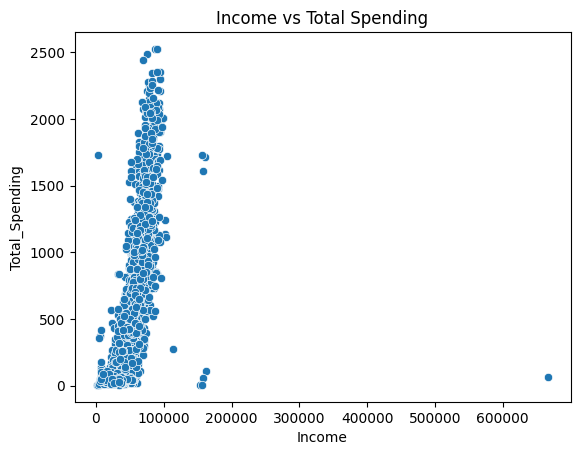

In [15]:
plt.figure()
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.title("Income vs Total Spending")
plt.show()

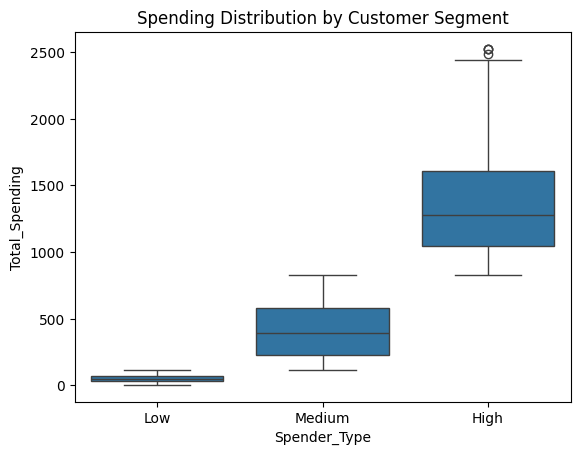

In [24]:
plt.figure()
sns.boxplot(x='Spender_Type', y='Total_Spending', data=df)
plt.title("Spending Distribution by Customer Segment")
plt.show()

While income positively correlates with spending, several high-income customers exhibit low purchase behavior, indicating potential for targeted premium marketing strategies

In [16]:
df['Luxury_Spending'] = df['MntWines'] + df['MntGoldProds']

df[['Luxury_Spending', 'Total_Spending']].describe()

,Luxury_Spending,Total_Spending
count,2240.000000,2240.000000
mean,347.957589,605.798214
std,360.039374,602.249288
min,2.000000,5.000000
25%,37.000000,68.750000
50%,221.500000,396.000000
75%,572.250000,1045.500000
max,1674.000000,2525.000000


In [17]:
# Top buyers
df.sort_values(by='Luxury_Spending', ascending=False)[['Income','Age','Luxury_Spending','Total_Spending']].head(10)

,Income,Age,Luxury_Spending,Total_Spending
1641,64140.0,62,1674,1750
2098,81929.0,50,1671,2053
1961,71670.0,64,1622,1766
987,75759.0,57,1576,2486
1488,76998.0,71,1556,1910
1749,80360.0,77,1536,2231
559,87771.0,67,1525,1957
824,87771.0,67,1525,1957
1052,69098.0,77,1493,2440
917,84169.0,44,1478,1919


In [18]:
df['Spender_Type'] = pd.qcut(df['Total_Spending'], q=3, labels=['Low','Medium','High'])
df['Spender_Type'].value_counts()

,count
Spender_Type,
Low,748
High,747
Medium,745


In [19]:
# How the bulk behaves vs top spenders
df.groupby('Spender_Type')['Total_Spending'].mean()

/tmp/ipykernel_2119/1273662649.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Spender_Type')['Total_Spending'].mean()


,Total_Spending
Spender_Type,
Low,51.219251
Medium,412.975839
High,1353.425703


The dataset reveals a small segment of high-value customers driving premium (wine/gold) purchases, while the majority exhibit moderate, routine spending behavior—suggesting a dual strategy of retention for high-value customers and upselling opportunities for mid-tier buyers

Customers who responded to marketing campaigns exhibit nearly double the average spending compared to non-responders, indicating that targeted campaigns are effectively engaging high-value customers rather than low-intent buyers.
While the majority of customers display moderate, routine spending behavior, a small segment of high-value customers drives premium purchases. Marketing campaigns appear highly effective in targeting these high-spending individuals, suggesting an opportunity to further refine segmentation strategies to convert high-income but low-spending customers.

In [20]:
df.groupby('Response')['Total_Spending'].mean()

,Total_Spending
Response,
0,538.929171
1,987.392216


The analysis reveals that a small segment of high-value customers drives premium purchases, while the majority exhibit moderate, routine spending behavior. Marketing campaigns are particularly effective in engaging these high-spending customers, as evidenced by nearly double spending among responders. This suggests an opportunity to further refine targeting strategies to convert high-income but low-spending individuals into premium customers

These insights can help businesses optimize marketing ROI by focusing on high-value segments while strategically nurturing mid-tier customers